In [1]:
import duckdb
import pandas as pd

In [2]:
# ler csv com duckdb e transformar em tabela SQL

dataset = r'dados\base_teste_tecnico.csv'

con = duckdb.connect()

con.execute(f"""
CREATE TABLE vendas AS
SELECT *
FROM read_csv_auto('{dataset}')
""")

In [3]:
# checar nomes das colunas e se há imperfeições visíveis

con.execute("""
SELECT *
FROM vendas
LIMIT 10
""").df()

,ano_mes_dia,loja,id_venda,id_cliente,faturamento
0,20250414,1,3D2C8C2AD0D66433E82A58FB5EC9DEDC,FC7E35E3C5B7B1F082F217FD984A5819,44.70
1,20250325,2,D07BB3CA6DC65BE3C812BC212040A8E8,7A8DAD40D0F099768A72FBDC91B92686,31.33
2,20250731,2,0C5E015645B1B7C8D20D6444EE4E6490,7F1F980AA088E2A428874D0C1A277B1A,191.23
3,20260117,1,B80CB58AE9463020AEE2356FD034E3D9,ACCE1F2B53C0862129C45DCE5FD79B04,57.15
4,20250131,1,A3C6EA6F59DF644A6CB74236E28D670B,96CB9CC81AC90D2DF67ED60257131281,195.86
5,20250504,2,3B7260A4AD48FF58472D7010B3FFB7DA,4AFF46B0ECBC19E4EFC67EC5E95E6C9E,22.46
6,20251113,1,C188E80C774611EBFFC6105947DC9F3C,B61B4B8B39819A6F8377612D25D9FFB2,54.74
7,20251108,2,A6B588EA558A74E94ADB483C1E5621F6,4140BC8DFA0BDB8C12E1F8E019ADB486,387.97
8,20260112,1,37A07FDC943D88998C028B202414CE3F,50142C84FA5D54CECF4D16C7AB4E9D23,60.89
9,20250128,2,A3E6C5EBD4547067E22A7960A271C7EC,8A733341A12B74B581D2DF78E729F689,7.88


In [4]:
# quantas linhas existem na base?

con.execute("""
SELECT COUNT(*) AS qtd_linhas
FROM vendas
""").df()

,qtd_linhas
0,309178


In [5]:
# quantidade de clientes únicos

con.execute("""
SELECT COUNT(DISTINCT id_cliente) AS clientes_unicos
FROM vendas
""").df()

,clientes_unicos
0,11684


In [6]:
# quantidade de lojas únicas

con.execute("""
SELECT COUNT(DISTINCT loja) AS lojas_unicas
FROM vendas
""").df()

,lojas_unicas
0,2


In [7]:
# data mais antiga e mais recente

con.execute("""
SELECT
    MIN(ano_mes_dia) AS data_mais_antiga,
    MAX(ano_mes_dia) AS data_mais_recente
FROM vendas
""").df()

,data_mais_antiga,data_mais_recente
0,20250102,20260531


In [8]:
#

con.execute("""
SELECT
    MIN(faturamento) AS faturamento_minimo,
    MAX(faturamento) AS faturamento_maximo,
    AVG(faturamento) AS faturamento_medio,
    MEDIAN(faturamento) AS mediana_faturamento
FROM vendas
""").df()

,faturamento_minimo,faturamento_maximo,faturamento_medio,mediana_faturamento
0,-1151.03,7000.0,78.325846,48.87


In [9]:
# há valores negativos de faturamento, o que pode significar erro ou alguma devolução de valor.
# quantos registros de faturamento negativo existem na base?

con.execute("""
SELECT
    COUNT(*) AS qtd_negativos,
    ROUND(
        100 * COUNT(*) / (SELECT COUNT(*) FROM vendas),
        2
    ) AS pencentual_negativos
FROM vendas
WHERE faturamento < 0
""").df()

,qtd_negativos,pencentual_negativos
0,286,0.09


In [10]:
# quantos clientes tem valores negativos de faturamento?

con.execute("""
SELECT COUNT(DISTINCT id_cliente) AS qtd_clientes_afetados
FROM vendas
WHERE faturamento < 0
""").df()

,qtd_clientes_afetados
0,252


In [11]:
# de qual quantia negativa estamos falando?

con.execute("""
SELECT
    SUM(faturamento) AS soma_negativos,
    AVG (faturamento) AS media_negativos,
    MIN(faturamento) AS valor_minimo
FROM vendas
WHERE faturamento < 0
""").df()

,soma_negativos,media_negativos,valor_minimo
0,-23124.88,-80.856224,-1151.03


In [12]:
# além dos negativos, existem linhas zeradas de faturamento?

con.execute("""
SELECT COUNT(*) AS qtd_zerados
FROM vendas
WHERE faturamento = 0
""").df()

,qtd_zerados
0,0


In [13]:
#

con.execute("""
SELECT
    APPROX_QUANTILE(faturamento, 0.25) AS q1,
    APPROX_QUANTILE(faturamento, 0.50) AS mediana,
    APPROX_QUANTILE(faturamento, 0.75) AS q3,
    APPROX_QUANTILE(faturamento, 0.95) AS p95,
    APPROX_QUANTILE(faturamento, 0.99) AS p99,
FROM vendas
""").df()

,q1,mediana,q3,p95,p99
0,25.22095,48.87138,93.872936,242.109571,479.813825


In [14]:
# De um total de 309178 registros, temos apenas 286 negativos, o que corresponde a 0.09% da base.
# Do total de 11684 clientes únicos, 252 apresentam valores negativos de faturamento, equivalendo a 2.2%

# Esses registros negativos provavelmente correspondem a devoluções ou cancelamentos.
# Portanto, dado o baixo impacto, vou desconsiderar eles da análise.


# Sobre os quantis, vemos que 99% das compras estão abaixo de R$ 480, porém o faturamento máximo é R$ 7000.
# Ou seja, há poucos registros extremamente elevados ao comparar com o resto da base.

In [15]:
# De 20250102 a 20260531, em quantos dias houve registro de compras?

con.execute("""
SELECT
    COUNT(DISTINCT ano_mes_dia) AS dias_com_compra
FROM vendas
""").df()

,dias_com_compra
0,504


In [16]:
# estatisticas dos dias de compra

con.execute("""
SELECT
    AVG(freq) AS media_dos_dias_de_compra,
    MEDIAN(freq) AS mediana_dos_dias_de_compra,
    MAX(freq) AS maximo_de_dias_de_compra
FROM(
    SELECT
        id_cliente,
        COUNT(DISTINCT ano_mes_dia) AS freq
    FROM vendas
    WHERE faturamento > 0
    GROUP BY id_cliente
)
""").df()

,media_dos_dias_de_compra,mediana_dos_dias_de_compra,maximo_de_dias_de_compra
0,24.07797,7.0,482


In [17]:
# quantos clientes compraram somente uma vez?

con.execute("""
SELECT
    COUNT(*) AS clientes_com_1_compra
FROM (
    SELECT
        id_cliente,
        COUNT(DISTINCT ano_mes_dia) AS freq
    FROM vendas
    WHERE faturamento > 0
    GROUP BY id_cliente
)
WHERE freq = 1
""").df()

,clientes_com_1_compra
0,2841


In [18]:
# A grande diferença entre média e mediana indica que existem 2 grupos diferentes: clientes ocasionais e recorrentes.

# 2841 clientes compraram apenas 1 vez. Isso representa 24% dos 11684 clientes únicos no período analisado.

In [19]:
# além de medir a frequência de compra dos clientes, é preciso ver a recência deles ao final do período.

con.execute("""
    WITH ultima_compra AS (
        SELECT
            id_cliente,
            MAX(ano_mes_dia) AS data_ultima_compra
        FROM vendas
        WHERE faturamento > 0
        GROUP BY id_cliente
    )
    SELECT
        MIN(data_ultima_compra),
        MAX(data_ultima_compra)
    FROM ultima_compra
""").df()

,min(data_ultima_compra),max(data_ultima_compra)
0,20250102,20260531


In [20]:
# muitos clientes ativos até recentemente ou pararam de fazer compras nesta rede há mais tempo?

con.execute("""
    WITH ultima_compra AS (
        SELECT
            id_cliente,
            MAX(ano_mes_dia) AS data_ultima_compra
        FROM vendas
        WHERE faturamento > 0
        GROUP BY id_cliente
    )
    SELECT
        data_ultima_compra,
        COUNT(*) AS qtd_clientes
    FROM ultima_compra
    GROUP BY data_ultima_compra
    ORDER BY data_ultima_compra DESC
    LIMIT 20
""").df()

,data_ultima_compra,qtd_clientes
0,20260531,428
1,20260530,597
2,20260529,696
3,20260528,282
4,20260527,250
5,20260526,244
6,20260525,174
7,20260524,142
8,20260523,211
9,20260522,161


In [21]:
# Muitos clientes continuam ativos até o final da base (histórico recente)

# Sabendo disso, vou definir o período de 20250102 até 20260228 para observar o comportamento dos clientes.
# O período de 20260301 até 20260531 será usado para ver quais clientes abandonaram (churn = 1) e quais continuaram comprando (churn = 0).

# Com essa definição, qual a quantidade de clientes que abandonaram?

con.execute("""
    WITH clientes_observados AS (
        SELECT DISTINCT id_cliente
        FROM vendas
        WHERE ano_mes_dia <= 20260228
            AND faturamento > 0
    ),
            
    clientes_futuro AS (
        SELECT DISTINCT id_cliente
        FROM vendas
        WHERE ano_mes_dia BETWEEN 20260301 AND 20260531
            AND faturamento > 0
    )
    
    SELECT
        CASE
            WHEN f.id_cliente IS NULL THEN 'churn'
            ELSE 'ativo'
        END AS status,
        COUNT(*) AS qtd
    FROM clientes_observados o
    LEFT JOIN clientes_futuro f
        ON o.id_cliente = f.id_cliente
    GROUP BY status
""").df()

,status,qtd
0,churn,4946
1,ativo,5941


# Etapa 1

### Base RFM
-Recência

-Frequência

-Monetário (valor total)


In [22]:
# Como os registros negativos representam apenas 0,09% da base, vamos desconsiderar eles ao construir as métricas.
# data de referência: 20260228
# Até essa data, 10887 dos 11684 clientes aparecem na base. O restante só aparece após essa data.
# Somente os 10887 clientes que já estavam no histórico foram considerados para a modelagem.
# Os 797 clientes novos não têm informações históricas o suficiente estimar risco de churn.

con.execute("""
    SELECT
        id_cliente,
        MAX(ano_mes_dia) AS data_compra_mais_recente,
        DATE_DIFF(
            'day',
            STRPTIME(CAST(MAX(ano_mes_dia) AS VARCHAR), '%Y%m%d'),
            DATE '2026-02-28'
        ) AS recencia,
        COUNT(DISTINCT ano_mes_dia) AS frequencia,
        SUM(faturamento) AS valor_total
    
    FROM vendas
    
    WHERE ano_mes_dia <= 20260228
        AND faturamento > 0
    
    GROUP BY id_cliente
""").df()

,id_cliente,data_compra_mais_recente,recencia,frequencia,valor_total
0,0BF0707AB8C51CB68F06590379B6BCEC,20260227,1,24,965.93
1,F50152013A840AD594B59945E4E715D7,20260220,8,85,4768.16
2,ADE6F7102970DC009BF87BABA12F6F81,20260130,29,35,2839.04
3,97BC82BDEFBCE5EE94A06F7617E057C1,20260224,4,106,9598.91
4,D2065A25AC627474F7C3662BC47502BF,20250901,180,6,50.29
...,...,...,...,...,...
10882,7B9CE847F5AD3B4007CBB53A21DE5833,20250514,290,1,38.53
10883,2ECE4A8C9136E4019F9AA19C01C0BB04,20250927,154,1,54.11
10884,F2D0917CB96D5F407F856B9924524446,20251031,120,1,15.61
10885,E4236B1E8BDCC0BEA48910958E2EFEA0,20250131,393,1,16.47


In [23]:
# adicionando a visão de churn na query acima:

con.execute("""
    WITH clientes_observados AS (
        SELECT
            id_cliente,
            MAX(ano_mes_dia) AS data_compra_mais_recente,
            DATE_DIFF(
                'day',
                STRPTIME(CAST(MAX(ano_mes_dia) AS VARCHAR), '%Y%m%d'),
                DATE '2026-02-28'
            ) AS recencia,
            COUNT(DISTINCT ano_mes_dia) AS frequencia,
            SUM(faturamento) AS valor_total
        FROM vendas
        WHERE ano_mes_dia <= 20260228
            AND faturamento > 0
        GROUP BY id_cliente
    ),
            
    clientes_futuro AS (
        SELECT
            id_cliente
        FROM vendas
        WHERE ano_mes_dia BETWEEN 20260301 AND 20260531
            AND faturamento > 0
        GROUP BY id_cliente
    )
    
    SELECT
        o.id_cliente,
        o.recencia,
        o.frequencia,
        o.valor_total,
        CASE
            WHEN f.id_cliente IS NULL THEN 1
            ELSE 0
        END AS churn
    FROM clientes_observados o
    LEFT JOIN clientes_futuro f
        ON o.id_cliente = f.id_cliente
""").df()

,id_cliente,recencia,frequencia,valor_total,churn
0,0BF0707AB8C51CB68F06590379B6BCEC,1,24,965.93,0
1,F50152013A840AD594B59945E4E715D7,8,85,4768.16,0
2,97BC82BDEFBCE5EE94A06F7617E057C1,4,106,9598.91,0
3,27CB333CE6CA6D76D701EDFA76D6C9F1,14,46,4231.79,0
4,A7534CDDA5010D037B466380CF5827B2,34,22,2055.16,0
...,...,...,...,...,...
10882,00D454EB0A6710CCDC7B6B90B7E0F53C,0,1,184.35,1
10883,7BB51C1ED06951D055E3A68CAF3E11C2,66,1,98.61,1
10884,97C88A2F888CDAB832A069F2D953CC1A,330,1,58.64,1
10885,46A67383968C77D1C176BCBAA275ED5F,345,1,84.52,1


# Etapa 2

### EDA (Análise Exploratória)


In [24]:
# As métricas FRM foram calculadas usando a data 20260228 como referência.
# Dados referentes ao período posterior foram usados para ver quais clientes continuaram ativos ou abandonaram (churn)

rfm = con.execute("""
    WITH clientes_observados AS (
        SELECT
            id_cliente,
            MAX(ano_mes_dia) AS data_compra_mais_recente,
            DATE_DIFF(
                'day',
                STRPTIME(CAST(MAX(ano_mes_dia) AS VARCHAR), '%Y%m%d'),
                DATE '2026-02-28'
            ) AS recencia,
            COUNT(DISTINCT ano_mes_dia) AS frequencia,
            SUM(faturamento) AS valor_total
        FROM vendas
        WHERE ano_mes_dia <= 20260228
            AND faturamento > 0
        GROUP BY id_cliente
    ),
            
    clientes_futuro AS (
        SELECT
            id_cliente
        FROM vendas
        WHERE ano_mes_dia BETWEEN 20260301 AND 20260531
            AND faturamento > 0
        GROUP BY id_cliente
    )
    
    SELECT
        o.id_cliente,
        o.recencia,
        o.frequencia,
        o.valor_total,
        CASE
            WHEN f.id_cliente IS NULL THEN 1
            ELSE 0
        END AS churn
    FROM clientes_observados o
    LEFT JOIN clientes_futuro f
        ON o.id_cliente = f.id_cliente
""").df()

In [25]:
rfm.describe()

,recencia,frequencia,valor_total,churn
count,10887.000000,10887.000000,10887.000000,10887.000000
mean,106.161936,21.235602,1814.854112,0.454303
std,123.128314,33.876255,3701.247354,0.497930
min,0.000000,1.000000,0.100000,0.000000
25%,7.000000,2.000000,122.385000,0.000000
50%,47.000000,7.000000,525.350000,0.000000
75%,180.500000,26.000000,2005.410000,1.000000
max,422.000000,395.000000,138509.020000,1.000000


A taxa média de churn da base é de 45%

In [26]:
rfm.groupby("churn")[["recencia", "frequencia", "valor_total"]].agg(["mean", "median"])

recencia        frequencia         valor_total          
             mean median       mean median         mean    median
churn                                                            
0       41.925770   11.0  34.823262   21.0  2975.347117  1547.980
1      183.320663  168.0   4.914476    2.0   420.901638   144.065

In [27]:
# Pela tabela acima, clientes com recencia maior parecem ter mais chance de churn
#   mediana de recencia dos ativos = 11 dias
#   mediana de recencia churn = 168 dias

# Outro ponto é que clientes com frequencia menor parecem ter mais chance de churn
#   mediana da frequencia dos ativos = 21 compras
#   mediana da frequencia churn = 2 compras

# Um terceiro ponto é que clientes com menor valor gasto parecem ter mais chance de churn
#   mediana do valor gasto dos ativos = R$ 1548
#   mediana do valor gasto churn = R$ 144

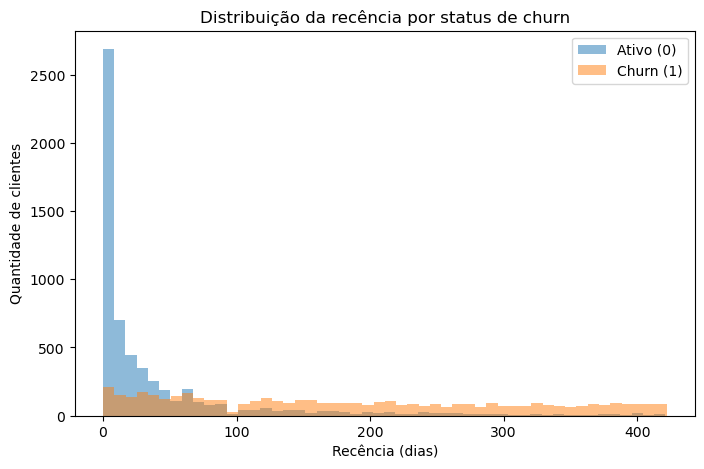

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# clientes ativos ficam concentrados próximos de 0
# recência baixa = comprou recentemente
# clientes churn apresentam recências maiores do que os clientes ativos, de modo geral

plt.figure(figsize=(8,5))

plt.hist(
    rfm.loc[rfm["churn"] == 0, "recencia"],
    bins=50,
    alpha=0.5,
    label="Ativo (0)"
)

plt.hist(
    rfm.loc[rfm["churn"] == 1, "recencia"],
    bins=50,
    alpha=0.5,
    label="Churn (1)"
)

plt.xlabel("Recência (dias)")
plt.ylabel("Quantidade de clientes")
plt.title("Distribuição da recência por status de churn")
plt.legend()

plt.show()

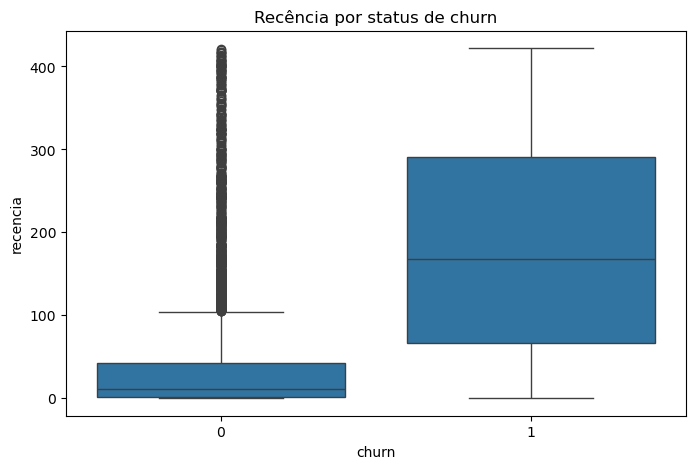

In [29]:
# a mediana da recência dos clientes churn é muito maior do que a dos clientes ativos.

plt.figure(figsize=(8,5))
sns.boxplot(data=rfm, x="churn", y="recencia")
plt.title("Recência por status de churn")
plt.show()

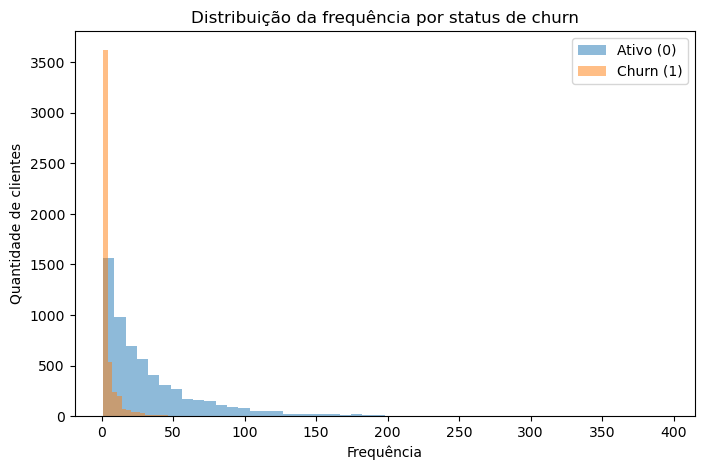

In [30]:
# o histograma de frequência mostra que os clientes que compram poucas vezes têm uma tendência maior a abandonar.

plt.figure(figsize=(8,5))

plt.hist(
    rfm.loc[rfm["churn"] == 0, "frequencia"],
    bins=50,
    alpha=0.5,
    label="Ativo (0)"
)

plt.hist(
    rfm.loc[rfm["churn"] == 1, "frequencia"],
    bins=50,
    alpha=0.5,
    label="Churn (1)"
)

plt.xlabel("Frequência")
plt.ylabel("Quantidade de clientes")
plt.title("Distribuição da frequência por status de churn")
plt.legend()

plt.show()

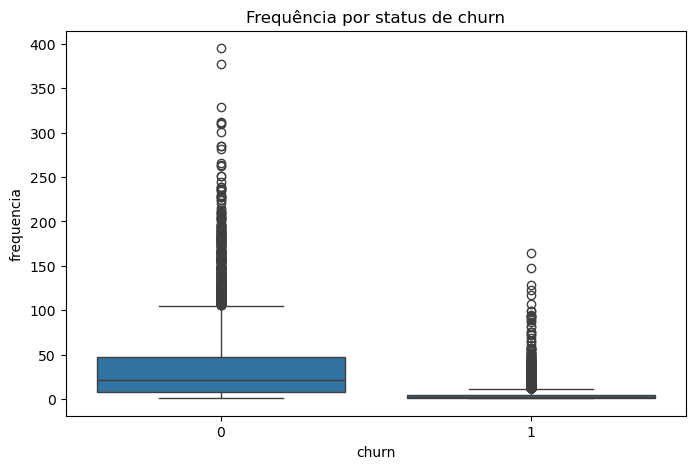

In [31]:
# a distribuição de frequência dos clientes ativos está deslocada para valores maiores

plt.figure(figsize=(8,5))
sns.boxplot(data=rfm, x="churn", y="frequencia")
plt.title("Frequência por status de churn")
plt.show()

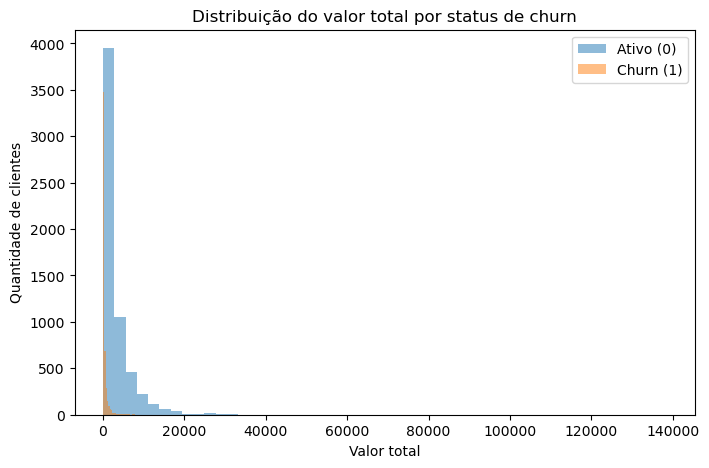

In [32]:
plt.figure(figsize=(8,5))

plt.hist(
    rfm.loc[rfm["churn"] == 0, "valor_total"],
    bins=50,
    alpha=0.5,
    label="Ativo (0)"
)

plt.hist(
    rfm.loc[rfm["churn"] == 1, "valor_total"],
    bins=50,
    alpha=0.5,
    label="Churn (1)"
)

plt.xlabel("Valor total")
plt.ylabel("Quantidade de clientes")
plt.title("Distribuição do valor total por status de churn")
plt.legend()

plt.show()

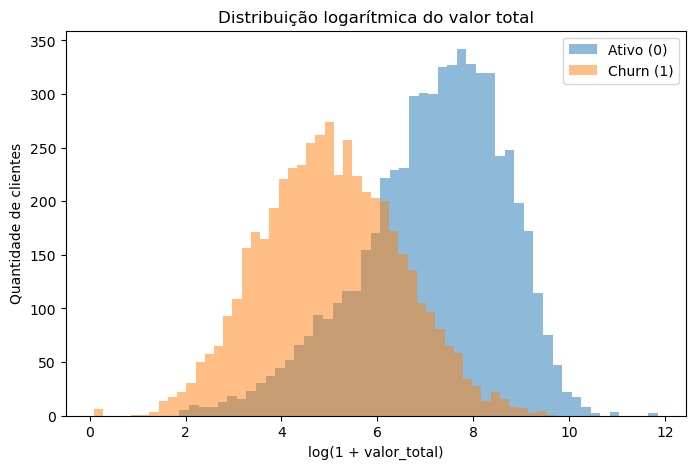

In [33]:
# o gráfico acima fica muito difícil de ler devido aos outliers.
# um histograma logarítmico ajuda na leitura

import numpy as np

# Clientes ativos tendem a acumular um valor de compras consideravelmente maior ao longo do período observado

rfm["log_valor_total"] = np.log1p(rfm["valor_total"])

plt.figure(figsize=(8,5))

plt.hist(
    rfm.loc[rfm["churn"] == 0, "log_valor_total"],
    bins=50,
    alpha=0.5,
    label="Ativo (0)"
)

plt.hist(
    rfm.loc[rfm["churn"] == 1, "log_valor_total"],
    bins=50,
    alpha=0.5,
    label="Churn (1)"
)

plt.xlabel("log(1 + valor_total)")
plt.ylabel("Quantidade de clientes")
plt.title("Distribuição logarítmica do valor total")
plt.legend()

plt.show()

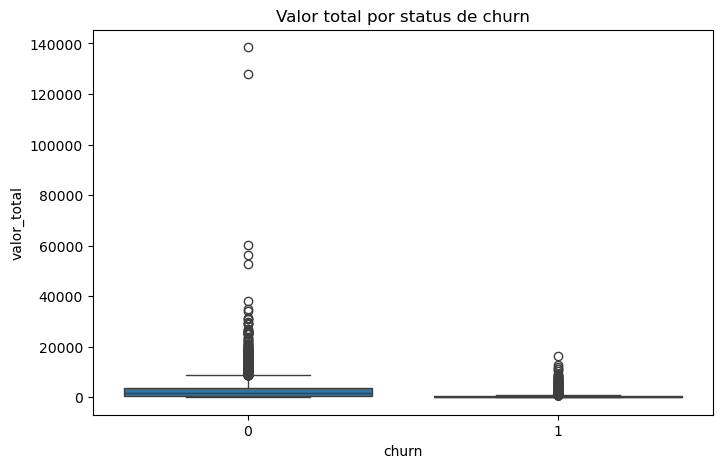

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=rfm, x="churn", y="valor_total")
plt.title("Valor total por status de churn")
plt.show()

Até aqui, foi possível ver que clientes que abandonaram têm uma recência bem maior que clientes ativos, o que pode significar que o tempo desde a última compra é um indicador relevante de abandono.

Em relação à frequência, nota-se que clientes ativos compram com muito mais frequência do que os clientes churn, o que pode indicar que o engajamento ao longo do tempo está ligado à retenção.

Por fim, sobre o valor total, clientes ativos acumulam valores maiores de compra em relação aos clientes churn. A visão em escala logarítmica ajudou a ver isso com maior clareza.

In [35]:
# existe correlação entre as variáveis?

rfm[["recencia", "frequencia", "valor_total"]].corr()

,recencia,frequencia,valor_total
recencia,1.000000,-0.420067,-0.327003
frequencia,-0.420067,1.000000,0.739006
valor_total,-0.327003,0.739006,1.000000


### recência x frequência -> -0.42
Essa correlação negativa indica que quem compra com maior frequência tende a ter recências menores (compras mais recentes).


### recência x valor -> -0.33
Clientes que gastam mais têm tendência a serem mais recentes.

### frequência x valor -> +0.74
Essa alta correlação positiva indica que clientes que compram mais vezes acabam acumulando maior valor gasto.

In [36]:
# taxa de churn por quartil de recência
# quanto o risco de churn aumenta conforme a recência aumenta?

rfm["faixa_recencia"] = pd.qcut(
    rfm["recencia"],
    q=4,
    duplicates="drop"
)

rfm.groupby("faixa_recencia", observed=True)["churn"].mean()

faixa_recencia
(-0.001, 7.0]     0.068413
(7.0, 47.0]       0.263100
(47.0, 180.5]     0.629849
(180.5, 422.0]    0.859662
Name: churn, dtype: float64

A análise cima mostra que quanto mais tempo o cliente passa sem comprar, maior é o risco de churn.

In [37]:
# taxa de churn por quartil de frequência
# quanto o risco de churn diminui conforme a frequência aumenta?

rfm["faixa_frequencia"] = pd.qcut(
    rfm["frequencia"],
    q=4,
    duplicates="drop"
)

rfm.groupby("faixa_frequencia", observed=True)["churn"].mean()

faixa_frequencia
(0.999, 2.0]     0.838252
(2.0, 7.0]       0.587031
(7.0, 26.0]      0.246183
(26.0, 395.0]    0.053120
Name: churn, dtype: float64

A análise acima mostra que quanto maior é a frequência de compra do cliente menor será o risco de churn.

In [38]:
# taxa de churn por quartil de valor
# quanto o risco de churn diminui conforme o valor aumenta?

rfm["faixa_valor"] = pd.qcut(
    rfm["valor_total"],
    q=4,
    duplicates="drop",
)

rfm.groupby("faixa_valor", observed=True)["churn"].mean()

faixa_valor
(0.099, 122.385]        0.826598
(122.385, 525.35]       0.631521
(525.35, 2005.41]       0.289967
(2005.41, 138509.02]    0.069067
Name: churn, dtype: float64

A análise acima mostra que clientes mais valiosos tem menor risco de churn.

Em resumo, as métricas RFM se mostraram bem capazes de discriminar entre clientes ativos e clientes churn. A taxa de churn aumenta conforme a recência aumenta, porém reduz conforme frequência e valor total aumentam.

Os resultados indicam que clientes mais engajados e com maior valor gasto têm uma probabilidade menor de abandono.

### Segmentação

Neste trecho vamos segmentar a base de clientes nos seguintes grupos:

-Campeões: compraram recentemente, com frequência e alto valor.

-Em risco: já foram bons, mas estão começando a sumir.

-Novos: compraram recentemente, mas tem pouco histórico.

-Baixo valor: poucas vezes comprou algo, e o valor gasto foi baixo.

-Regulares: todo o resto.

In [39]:
# aqui serão criados scores RFM, transformando cada métrica em quartil

# quanto maior, melhor
rfm["F_score"] = pd.qcut(
    rfm["frequencia"],
    q=4,
    labels=[1,2,3,4],
    duplicates="drop"
).astype(int)

# quanto maior, melhor
rfm["M_score"] = pd.qcut(
    rfm["valor_total"],
    q=4,
    labels=[1,2,3,4],
    duplicates="drop"
).astype(int)

# quanto menor, melhor
rfm["R_score"] = pd.qcut(
    rfm["recencia"],
    q=4,
    labels=[4,3,2,1],
    duplicates="drop"
).astype(int)


# a partir desses scores, é criado o score total
rfm["RFM_score"] = (
    rfm["R_score"] +
    rfm["F_score"] +
    rfm["M_score"]
)

In [40]:
rfm[["R_score","F_score","M_score"]].describe()

,R_score,F_score,M_score
count,10887.000000,10887.000000,10887.000000
mean,2.503720,2.411500,2.499954
std,1.120254,1.176523,1.118126
min,1.000000,1.000000,1.000000
25%,1.500000,1.000000,1.500000
50%,3.000000,2.000000,2.000000
75%,4.000000,3.000000,3.500000
max,4.000000,4.000000,4.000000


In [41]:
# esse trecho serve para mostrar os grupos mais frequentes

rfm.groupby(
    ["R_score","F_score","M_score"]
).size().sort_values(ascending=False).head(20)

R_score  F_score  M_score
4        4        4          1537
1        1        1          1352
2        1        1           710
3        3        3           653
1        1        2           558
3        4        4           544
2        2        2           482
         3        3           449
4        3        3           410
1        2        2           346
3        2        2           310
2        1        2           307
3        1        1           272
4        4        3           235
3        3        4           225
         4        3           219
2        2        3           206
4        3        4           178
3        3        2           173
2        3        2           152
dtype: int64

Os grupos mais frequentes nessa base são:

- 444: compra recente, compram com muita frequência, gastam muito

- 111: não compra faz tempo, compraram poucas vezes, gastam pouco

### Clientes campeões

In [47]:
# segmento 1: campeões
# clientes acima da mediana em recência, frequência e valor

rfm["segmento"] = "Regular"

rfm.loc[
    (rfm["R_score"] >= 3) &
    (rfm["F_score"] >= 3) &
    (rfm["M_score"] >= 3),
    "segmento"
] = "Campeao"

In [43]:
rfm["segmento"].value_counts()

segmento
Regular    6886
Campeao    4001
Name: count, dtype: int64

In [46]:
# o resultado acima diz que 37% dos clientes podem ser considerados campeões
# vale analisar a taxa de churn desse grupo com o código abaixo

rfm.loc[
    rfm["segmento"] == "Campeao",
    ["recencia", "frequencia", "valor_total", "churn"]
].describe()

,recencia,frequencia,valor_total,churn
count,4001.000000,4001.000000,4001.000000,4001.000000
mean,10.146713,48.816296,4202.221597,0.055986
std,11.921083,42.387693,5211.220325,0.229923
min,0.000000,8.000000,526.730000,0.000000
25%,1.000000,20.000000,1432.640000,0.000000
50%,5.000000,35.000000,2727.910000,0.000000
75%,15.000000,64.000000,5298.720000,0.000000
max,47.000000,395.000000,138509.020000,1.000000


A taxa média de churn do grupo dos campões é de 5.6%, o que mostra que 94.4% continuam comprando.

In [48]:
# Ao olhar para o restante dos clientes, a mediana de churn é 1, o que indica que boa parte desse grupo abandonou o comportamento de compra.

rfm.groupby("segmento")[
    ["recencia", "frequencia", "valor_total", "churn"]
].median()

,recencia,frequencia,valor_total,churn
segmento,,,,
Campeao,5.0,35.0,2727.910,0.0
Regular,135.0,2.0,183.595,1.0


### Clientes em risco de churn

In [55]:
# para o segmento "em risco" é preciso ignorar os campeões para evitar conflitos entre os segmentos.
# somente os "regulares" serão usados para classificar o novo segmento.

# para os clientes em risco foi usado o pior quartil de recência, e a frequência acima do quartil mais baixo
# clientes há muito tempo sem comprar, mas que já foram pelo menos um pouco engajados

rfm.loc[
    (rfm["segmento"] == "Regular") &
    (rfm["R_score"] == 1) &
    (rfm["F_score"] >= 2),
    "segmento"
] = "Em_Risco"

In [50]:
rfm["segmento"].value_counts()

segmento
Regular     6121
Campeao     4001
Em_Risco     765
Name: count, dtype: int64

Os clientes "em risco" representam 7,0% da base (765 / 10887).

In [53]:
# assim como no grupo dos campeões, é preciso analisar a taxa de churn deste segmento

rfm.loc[
    rfm["segmento"] == "Em_Risco",
    ["recencia", "frequencia", "valor_total", "churn"]
].describe()

,recencia,frequencia,valor_total,churn
count,765.000000,765.000000,765.000000,765.000000
mean,263.258824,7.107190,599.181111,0.794771
std,60.687820,7.891709,765.370029,0.404133
min,181.000000,3.000000,29.760000,0.000000
25%,210.000000,3.000000,193.840000,1.000000
50%,252.000000,5.000000,366.960000,1.000000
75%,308.000000,8.000000,715.900000,1.000000
max,413.000000,89.000000,7405.480000,1.000000


A taxa média de churn do grupo "em risco" é de 79.5%, o que valida a ideia de categorizar estes clientes como arriscados.

In [54]:
# Ao comparar com o restante dos clientes, a mediana de churn é 1, o que indica que boa parte desse grupo abandonou o comportamento de compra.
# ainda assim, o grupo "em risco" compra com mais frequência do que os "regulares", apesar de ficarem mais tempo sem comprar (recência maior).

rfm.groupby("segmento")[
    ["recencia", "frequencia", "valor_total", "churn"]
].median()

,recencia,frequencia,valor_total,churn
segmento,,,,
Campeao,5.0,35.0,2727.91,0.0
Em_Risco,252.0,5.0,366.96,1.0
Regular,116.0,2.0,161.21,1.0


### Clientes novos/promissores

In [56]:
# para o segmento "novos" serão considerados clientes recentes (R_score = 4) mas que compraram poucas vezes ainda (F_score <=2)
# mais uma vez, pegando só os clientes que sobraram no segmento "regular"

rfm.loc[
    (rfm["segmento"] == "Regular") &
    (rfm["R_score"] == 4) &
    (rfm["F_score"] <= 2),
    "segmento"
] = "Novo_Promissor"

In [57]:
rfm["segmento"].value_counts()

segmento
Regular           5836
Campeao           4001
Em_Risco           765
Novo_Promissor     285
Name: count, dtype: int64

Os clientes novos/promissores representam 2,6% da base (285 / 10887)

In [58]:
# assim como nos outros grupos, é preciso analisar a taxa de churn deste segmento

rfm.loc[
    rfm["segmento"] == "Novo_Promissor",
    ["recencia", "frequencia", "valor_total", "churn"]
].describe()

,recencia,frequencia,valor_total,churn
count,285.000000,285.000000,285.000000,285.000000
mean,2.614035,3.396491,358.318982,0.414035
std,2.407108,2.106493,512.827363,0.493421
min,0.000000,1.000000,6.380000,0.000000
25%,1.000000,1.000000,84.650000,0.000000
50%,1.000000,3.000000,204.190000,0.000000
75%,5.000000,5.000000,445.720000,1.000000
max,7.000000,7.000000,6309.000000,1.000000


A taxa média de churn do grupo "em risco" é de 41.4%, o que valida a ideia de categorizar estes clientes como novos/promissores, pois apesar de terem um risco mais baixo de churn, a chance de abandonarem está longe de ser zero.

In [59]:
rfm.groupby("segmento")[
    ["recencia", "frequencia", "valor_total", "churn"]
].median()

,recencia,frequencia,valor_total,churn
segmento,,,,
Campeao,5.0,35.0,2727.910,0.0
Em_Risco,252.0,5.0,366.960,1.0
Novo_Promissor,1.0,3.0,204.190,0.0
Regular,121.0,2.0,158.925,1.0


O resultado acima conversa com a ideia de segmentar esses clientes como novos/promissores. A recência mediana é 1 dia, a frequência é de 3 compras, e o faturamento ainda é baixo. Portanto ainda não tiveram tempo para construir um histórico de compras.

In [61]:
# tabela resumo

resumo_segmentos = (
    rfm.groupby("segmento")
    .agg({
        "id_cliente": "count",
        "recencia": "median",
        "frequencia": "median",
        "valor_total": "median",
        "churn": "mean"
    })
    .rename(columns={
        "id_cliente": "qtd_clientes",
        "churn": "taxa_churn"
    })
)

resumo_segmentos

,qtd_clientes,recencia,frequencia,valor_total,taxa_churn
segmento,,,,,
Campeao,4001,5.0,35.0,2727.910,0.055986
Em_Risco,765,252.0,5.0,366.960,0.794771
Novo_Promissor,285,1.0,3.0,204.190,0.414035
Regular,5836,121.0,2.0,158.925,0.684716


# Etapa 3

### Modelo de classificação

In [67]:
# Definição de churn usada: cliente que comprou até 28/02/2026 mas não realizou nenhuma compra entre 01/03/2026 e 31/05/2026.
# churn = 1 caso não tenha feito uma compra nos 3 meses seguintes
# churn = 0 caso contrário

# Modelo escolhido: regressão logística
#   é simples e fornece importância das variáveis, além de ser amplamente usado para modelagem de churn.


# variáveis explicativas (features)
X = rfm[[
    "recencia",
    "frequencia",
    "valor_total"
]]


# variável alvo (target)
y = rfm["churn"]

In [68]:
# aqui será feita a separação entre dados de treino e dados de teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% para teste e 80% para treino
    random_state=42,    # sorteio dos clientes para treino/teste é aleatório
    stratify=y          # treino e teste mantém a proporção 45% churn e 55% não churn já medida
)

In [66]:
print(X_train.shape)
print(X_test.shape)

print(y_train.mean())
print(y_test.mean())

(8709, 3)
(2178, 3)
0.4543575611436445
0.4540863177226814


- 8709 clientes para treinar o modelo (80%)

- 2178 clientes para testar o modelo (20%)

- a proporção de churn para treino e teste ficou praticamente igual

In [69]:
# agora é preciso padronizar as variáveis recencia, frequencia e valor_total

# a Regressão Logística irá calcular coeficientes para cada variável
# se uma variável está em uma escala muito maior que as outras, ela pode dominar os cálculos do modelo


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [73]:
X_train

,recencia,frequencia,valor_total
9050,93,5,127.69
1262,379,2,132.11
9123,6,68,6358.09
5317,134,7,572.14
4624,59,1,341.39
...,...,...,...
884,1,20,585.85
9068,3,5,270.47
10264,44,23,1489.38
68,6,86,2320.63


In [74]:
X_train_scaled[:5]

array([[-0.10954672, -0.47969973, -0.44292938],
       [ 2.21128982, -0.5682048 , -0.44178229],
       [-0.81553545,  1.3789068 ,  1.17400636],
       [ 0.22316062, -0.42069635, -0.32758412],
       [-0.38545036, -0.5977065 , -0.38746919]])

In [75]:
# agora será treinada a regressão logística

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [81]:
# previsões

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

O desempenho do modelo será avaliado utilizando ROC-AUC e métricas de classificação (precision, recall e f1-score), uma vez que o problema de churn envolve risco assimétrico de erro.

In [79]:
# métrica 1

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

ROC-AUC: 0.8897817115265396


ROC-AUC de 0.89 indica boa capacidade de separação entre clientes com e sem risco de churn.

In [80]:
# métrica 2

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1189
           1       0.80      0.80      0.80       989

    accuracy                           0.82      2178
   macro avg       0.82      0.82      0.82      2178
weighted avg       0.82      0.82      0.82      2178



- Recall classe 1 = 0.80 -> significa que estão sendo capturados 80% dos churners

- O modelo apresentou bom equilíbrio entre precision e recall.

A importância das variáveis será analisada através dos coeficientes do modelo de regressão logística, permitindo interpretar o impacto de cada feature na probabilidade de churn.

In [82]:
# feature importance

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_[0]
})

feature_importance["abs_coef"] = np.abs(feature_importance["coef"])
feature_importance = feature_importance.sort_values("abs_coef", ascending=False)

print(feature_importance)

       feature      coef  abs_coef
1   frequencia -2.065328  2.065328
0     recencia  1.027093  1.027093
2  valor_total -0.613141  0.613141


- frequencia: negativo. quanto mais compras são feitas, menor o churn

- recencia: positiva, o que sugere que quanto maior o tempo sem comprar, maior o churn

- valor_total: negativo. clientes mais valiosos (que gastam mais) tendem a permanecer

As probabilidades previstas de churn serão utilizadas para ranquear clientes em risco. Isso possibilitará elaboração de ações de retenção direcionadas a estes clientes.

In [83]:
# ranking de probabilidade de churn

rfm_test = X_test.copy()
rfm_test["churn_proba"] = y_proba
rfm_test["y_true"] = y_test.values

rfm_test.sort_values("churn_proba", ascending=False).head(10)

,recencia,frequencia,valor_total,churn_proba,y_true
538,422,1,13.14,0.966395,1
1289,422,1,16.74,0.966377,1
8065,422,1,50.61,0.966201,1
650,421,1,18.46,0.966096,1
5089,420,1,75.92,0.965519,0
4372,418,1,18.45,0.965267,1
7395,420,1,151.21,0.965117,1
1733,418,1,62.97,0.965029,1
7038,417,1,16.45,0.964997,1
5408,417,1,26.22,0.964945,0


No ranking de probabilidade de churn podemos ver clientes críticos. É observado que clientes com alta recência e baixa frequência concentram as maiores probabilidades de churn.

# Etapa 4

### Montar dataset final para exportação

In [84]:
df_resultado = X_test.copy()

df_resultado["id_cliente"] = rfm.loc[X_test.index, "id_cliente"].values
df_resultado["churn_real"] = y_test.values
df_resultado["churn_pred"] = y_pred
df_resultado["churn_proba"] = y_proba


def segmento_risco(prob):
    if prob >= 0.7:
        return "Alto risco"
    elif prob >= 0.4:
        return "Médio risco"
    else:
        return "Baixo risco"

df_resultado["segmento_risco"] = df_resultado["churn_proba"].apply(segmento_risco)


# flag para marcar se o modelo acertou
df_resultado["acerto_churn"] = (
    (df_resultado["churn_pred"] == 1) &
    (df_resultado["churn_real"] == 1)
)

In [85]:
df_resultado = df_resultado[[
    "id_cliente",
    "recencia",
    "frequencia",
    "valor_total",
    "churn_real",
    "churn_pred",
    "churn_proba",
    "segmento_risco",
    "acerto_churn"
]]

In [87]:
df_resultado.to_csv(r'dados\resultado_churn_modelo.csv', index=False)